In [2]:
import warnings

from tqdm import tqdm

warnings.filterwarnings("ignore")
import os
import shutil

import matplotlib
import pandas as pd

import codecs  # this is used for file operations
import gc
import multiprocessing
import pickle
import pickle as pkl
import random as r
import re
from datetime import datetime as dt
from multiprocessing import Process  # this is used for multithreading

import dask.dataframe as dd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import scipy.sparse
import seaborn as sns
from itertools import product
from pathlib import Path
from nltk.util import ngrams
from sklearn import preprocessing
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, f_regression
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, log_loss
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import uniform, randint
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

In [3]:
root_path = "./"

In [4]:
# Unigram of Byte Files + Size of Byte Files +
uni_gram_byte_features__with_size = pd.read_parquet(
    root_path + "byte_file_feature_size.parquet"
).drop(["??", "size", "Class", "00", "FF"], axis=1)

uni_gram_byte_features__with_size.rename(columns={'Id': 'ID'}, inplace=True)
uni_gram_byte_features__with_size

,ID,01,02,03,04,05,06,07,08,09,...,F5,F6,F7,F8,F9,FA,FB,FC,FD,FE
0,01SuzwMJEIXsK7A8dQbl,710,302,433,559,410,262,249,422,223,...,345,483,847,947,350,209,239,653,221,242
1,01kcPWA9K2BOxQeS5Rju,1213,726,817,1257,625,550,523,1078,473,...,348,446,478,873,485,462,516,1133,471,761
2,02IOCvYEy8mjiuAQHax3,414,340,331,350,324,303,299,327,364,...,313,308,317,305,295,333,344,325,332,321
3,02mlBLHZTDFXGa7Nt6cr,430,311,410,411,330,385,863,345,378,...,291,340,425,333,312,272,279,295,300,334
4,04hSzLv5s2TDYPlcgpHB,725,304,472,294,337,199,213,240,200,...,274,300,385,564,313,276,264,504,342,469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10863,lS0IVqXeJrN6Dzi9Pap1,373,385,432,495,399,393,373,399,341,...,337,327,374,323,376,328,338,479,337,350
10864,LoWgaidpb2IUM5ACcSGO,437,453,506,511,390,431,407,405,412,...,381,374,416,357,377,376,352,543,361,330
10865,L1OGj5BEh2drf0Wtiu9N,59,26,44,37,24,11,10,15,3,...,29,21,24,16,33,26,23,36,34,22
10866,L2QwdUyG0HISDVk8rcsE,115033,8473,100,133935,110452,55,19,7827,74,...,5,46,10,8743,53,15507,37,31,4,66


In [5]:
# Top 52 Unigram of ASM Files  + Size of ASM Files
# Droping .BSS, .rtn, .CODE features from the unigram_asm_feature__with_size (which is the unigram of asm files) dataset
# As we earlier saw that these features were not much important in separating class labels
unigram_asm_feature__with_size = pd.read_csv(
    root_path + "featurization/unigram_asm_feature__with_size"
).drop(["Class", "rtn", ".BSS:", ".CODE", "HEADER:", "size", ".rdata:", ".data:"], axis=1)
unigram_asm_feature__with_size

,ID,.text:,.Pav:,.idata:,.bss:,.edata:,.rsrc:,.tls:,.reloc:,jmp,...,eax,ebx,ecx,edi,ebp,esp,eip,.dll,std::,:dword
0,01IsoiSMh5gxyDYTl4CB,109939,0,616,0,0,0,0,0,47,...,1446,260,1090,391,905,420,0,24,22,227
1,01jsnpXSAlgw6aPeDxrU,68883,0,304,0,0,0,0,0,1,...,903,5,547,5,451,56,0,27,0,117
2,02JqQ7H3yEoD8viYWlmS,129362,0,644,0,0,0,0,0,48,...,480,147,353,168,375,63,0,22,0,236
3,02K5GMYITj7bBoAisEmD,93532,0,503,0,0,0,0,0,389,...,19726,12761,17438,13613,6078,301,0,44,17,209
4,02MRILoE6rNhmt7FUi45,5372,0,606,0,0,0,0,0,79,...,835,263,665,291,664,256,0,19,16,203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10863,Lf5U8qioZ9yOkjrGT37A,564,0,107,0,0,3,0,0,1,...,36,20,16,11,12,20,0,4,0,41
10864,LivEmF2ytpsDexIVWuYR,3403,0,3,0,3,3,0,0,273,...,279,189,152,122,93,135,0,0,0,0
10865,lkqEXK4NrYSseRTt0Gb3,2692,0,0,0,0,0,0,0,124,...,182,96,69,72,33,134,0,0,0,0
10866,loIP1tiwELF9YNZQjSUO,631,0,109,0,0,3,0,0,2,...,43,29,16,8,15,17,0,4,0,42


In [6]:
# Top 2000 Bi-Gram of Byte files
# top_2000_imp_byte_bigram_df = pd.read_csv(
#     root_path + "featurization/featurization_final/top_2000_imp_byte_bigram_df.csv"
# ).drop(columns=["ID.1"])

top_2000_imp_byte_bigram_df_train = pd.read_csv(
    root_path + "featurization/featurization_final/top_1000_imp_byte_bigram_df_train.csv"
).drop(["?? ??"], axis=1)
top_2000_imp_byte_bigram_df_test = pd.read_csv(
    root_path + "featurization/featurization_final/top_1000_imp_byte_bigram_df_test.csv"
).drop(["?? ??"], axis=1)
top_2000_imp_byte_bigram_df_test

,ID,00 00,00 01,00 02,00 03,00 04,00 05,00 06,00 07,00 08,...,ff 71,ff 72,ff 75,ff 76,ff 79,ff 7f,ff 83,ff 89,ff 8b,ff ff
0,01jsnpXSAlgw6aPeDxrU,16798,596,159,144,513,595,557,146,528,...,90,112,352,86,96,83,367,99,823,2358
1,02JqQ7H3yEoD8viYWlmS,27980,843,158,122,2403,112,100,99,104,...,179,200,551,285,294,225,558,461,412,10513
2,04EjIdbPV5e1XroFOpiN,24462,357,201,200,109,55,35,185,78,...,5,2,819,85,2,9,234,106,750,3852
3,04QzZ3DVdPsEp9elLR65,3388,26,14,46,15,33,16,24,16,...,30,21,20,14,16,23,36,11,28,76
4,05LHG8fR3iPn6agIo9z7,99187,357,274,429,275,253,293,333,266,...,130,130,221,132,156,133,176,136,157,31160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2169,kfigr70cURVxjFCabY4n,22353,780,106,72,215,23,30,29,64,...,227,281,620,282,284,231,442,442,661,5446
2170,kiLT9E8NrJAdchnwvBt6,2259,34,24,38,20,17,15,21,26,...,11,4,103,7,6,7,8,13,18,241
2171,l1OdNtIKM8Gi6jowZHg3,4606,14,2,6,1,1,1,2,3,...,0,0,0,0,0,0,1,0,0,84
2172,l1yeU9NCErfuov4GIXj6,4813,5,5,15,2,11,6,7,1,...,1,2,8,1,1,3,30,2,17,803


In [7]:
# Top 500 Bigram of Opcodes of ASM Files
top_500_asm_bigram_df = pd.read_csv(root_path + "featurization/featurization_final/top_500_asm_opcodes_bigram_df.csv")
top_500_asm_bigram_df

,ID,mov jmp,push retf,push jmp,push cmp,imul jmp,mov add,mov retf,call jmp,mov cmp,...,jnb ror,retn call,sub rol,jmp shl,call call,inc add,shr xor,call or,nop mov,rol mov
0,01azqd4InC7m9JpocGv5,165,0,0,2,2,219,0,58,285,...,0,0,0,2,51,1,0,3,0,0
1,01IsoiSMh5gxyDYTl4CB,34,0,0,3,0,114,0,1,74,...,0,4,0,0,2,2,0,0,4,0
2,01jsnpXSAlgw6aPeDxrU,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,0,0,12,0,0
3,01kcPWA9K2BOxQeS5Rju,3,0,0,0,0,2,0,2,6,...,0,0,0,0,0,0,0,0,0,0
4,01SuzwMJEIXsK7A8dQbl,51,2,1,0,0,389,0,0,144,...,0,0,0,0,67,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10863,loIP1tiwELF9YNZQjSUO,2,0,0,18,0,15,12,0,8,...,0,1,0,0,3,3,0,5,12,2
10864,LOP6HaJKXpkic5dyuVnT,19,10,27,25,0,79,0,3,2,...,0,0,2,1,1,1,0,5,25,0
10865,LOqA6FX02GWguYrI1Zbe,5,0,9,0,1,11,0,3,20,...,0,0,0,0,0,0,1,1,0,0
10866,LoWgaidpb2IUM5ACcSGO,171,0,195,20,1,28,24,14,18,...,0,1,0,1,0,7,1,0,26,4


In [8]:
# Top 800 Trigram of Opcodes of ASM Files
top_800_asm_trigam_df = pd.read_csv(root_path + "featurization/featurization_final/top_800_asm_opcodes_trigram_df.csv")
top_800_asm_trigam_df

,ID,mov mov jmp,push push retf,mov mov add,imul mov jmp,mov imul jmp,push push cmp,push call jmp,mov push retf,push mov retf,...,cmp add jmp,cmp lea cmp,sub add jmp,jmp add jmp,cmp lea shr,add mov or,add mov sub,mov movzx dec,retf retf jmp,jz rtn movzx
0,01azqd4InC7m9JpocGv5,37,0,131,6,1,1,16,0,0,...,2,0,0,4,0,3,5,0,0,0
1,01IsoiSMh5gxyDYTl4CB,4,0,78,0,0,0,1,0,0,...,0,0,0,0,0,2,10,1,0,0
2,01jsnpXSAlgw6aPeDxrU,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,01kcPWA9K2BOxQeS5Rju,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,01SuzwMJEIXsK7A8dQbl,20,0,305,0,0,0,0,0,0,...,0,0,0,0,0,0,4,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10863,loIP1tiwELF9YNZQjSUO,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10864,LOP6HaJKXpkic5dyuVnT,1,2,1,0,0,0,3,0,0,...,0,0,0,1,0,0,0,0,0,0
10865,LOqA6FX02GWguYrI1Zbe,1,0,1,0,0,0,1,0,0,...,0,0,0,2,0,0,0,0,0,0
10866,LoWgaidpb2IUM5ACcSGO,4,0,2,0,0,9,0,0,0,...,2,1,1,65,0,0,1,0,0,0


In [9]:
%%time

# Initiate a dataframe for representing the Combined Features
# and set it equal to uni_gram_byte_features__with_size
combined_features_final_df_train = uni_gram_byte_features__with_size
# combined_features_final_df_train = unigram_asm_feature__with_size

individual_featuarized_dfs = [
    unigram_asm_feature__with_size,
    top_2000_imp_byte_bigram_df_train,
    top_500_asm_bigram_df,
    # top_800_asm_trigam_df
]

for df in tqdm(individual_featuarized_dfs):
    # combined_features_final_df = pd.merge(combined_features_final_df, df, on="ID", how="left")
    combined_features_final_df_train = pd.merge(combined_features_final_df_train, df, on="ID", suffixes=('_byte', '_asm'))

combined_features_final_df_train.to_csv(
    root_path + "featurization/featurization_final/combined_features_final_df_train.csv",
    index=False,
)

# Initiate a dataframe for representing the Combined Features
# and set it equal to uni_gram_byte_features__with_size
combined_features_final_df_test = uni_gram_byte_features__with_size
# combined_features_final_df_test = unigram_asm_feature__with_size

individual_featuarized_dfs = [
    unigram_asm_feature__with_size,
    top_2000_imp_byte_bigram_df_test,
    top_500_asm_bigram_df,
    # top_800_asm_trigam_df
]

for df in tqdm(individual_featuarized_dfs):
    # combined_features_final_df = pd.merge(combined_features_final_df, df, on="ID", how="left")
    combined_features_final_df_test = pd.merge(combined_features_final_df_test, df, on="ID", suffixes=('_byte', '_asm'))

combined_features_final_df_test.to_csv(
    root_path + "featurization/featurization_final/combined_features_final_df_test.csv",
    index=False,
)

combined_features_final_df_train

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 39.97it/s]


CPU times: total: 4.73 s
Wall time: 5.02 s


,ID,01,02,03,04,05,06,07,08,09,...,jnb ror,retn call,sub rol,jmp shl,call call,inc add,shr xor,call or,nop mov,rol mov
0,01SuzwMJEIXsK7A8dQbl,710,302,433,559,410,262,249,422,223,...,0,0,0,0,67,0,0,0,0,0
1,01kcPWA9K2BOxQeS5Rju,1213,726,817,1257,625,550,523,1078,473,...,0,0,0,0,0,0,0,0,0,0
2,02IOCvYEy8mjiuAQHax3,414,340,331,350,324,303,299,327,364,...,0,0,0,0,0,0,1,0,0,0
3,02mlBLHZTDFXGa7Nt6cr,430,311,410,411,330,385,863,345,378,...,0,0,0,0,0,1,0,0,0,0
4,04hSzLv5s2TDYPlcgpHB,725,304,472,294,337,199,213,240,200,...,0,0,0,0,70,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8689,loIP1tiwELF9YNZQjSUO,1177,1072,1222,1238,1159,1143,1126,1149,1141,...,0,1,0,0,3,3,0,5,12,2
8690,lkqEXK4NrYSseRTt0Gb3,637,460,771,538,557,460,566,477,599,...,0,0,1,2,1,1,0,1,0,2
8691,KpzMHfmGQJbXN92Sdsyx,91858,98633,97258,16735,10877,16024,10540,13063,289,...,0,1,0,0,1,1,0,0,1,0
8692,lS0IVqXeJrN6Dzi9Pap1,373,385,432,495,399,393,373,399,341,...,0,1,1,4,0,4,0,0,29,1


In [10]:
with open('featurization/class_labels.pkl', 'rb') as file:
    class_labels = pkl.load(file)
y_labels = class_labels.rename(columns={"Id": "ID", "Class": "Class"})

combined_features_final_df_train = pd.merge(combined_features_final_df_train, y_labels, on="ID", suffixes=('_byte', '_asm'))
combined_features_final_df_test = pd.merge(combined_features_final_df_test, y_labels, on="ID", suffixes=('_byte', '_asm'))

final_X_train = combined_features_final_df_train.fillna(0).drop(['ID', 'Class'], axis=1, errors="ignore")
final_y_train = combined_features_final_df_train["Class"] - 1
final_X_test = combined_features_final_df_test.fillna(0).drop(['ID', 'Class'], axis=1, errors="ignore")
final_y_test = combined_features_final_df_test["Class"] - 1

# train val
X_train_final_merged, X_cv_final_merged, y_train_final_merged, y_cv_final_merged = train_test_split(final_X_train, final_y_train, stratify=final_y_train, test_size=0.20, random_state=42)
X_test_final_merged = final_X_test
y_test_final_merged = final_y_test
print('Shape of X_train_final_merged and y_train_final_merged: ', X_train_final_merged.shape, y_train_final_merged.shape)

print('Shape of X_test_final_merged and y_test_final_merged: ', X_test_final_merged.shape, y_test_final_merged.shape)

print('Shape of X_cv_final_merged and y_cv_final_merged ', X_cv_final_merged.shape, y_cv_final_merged.shape)

Shape of X_train_final_merged and y_train_final_merged:  (6955, 2797) (6955,)
Shape of X_test_final_merged and y_test_final_merged:  (2174, 2797) (2174,)
Shape of X_cv_final_merged and y_cv_final_merged  (1739, 2797) (1739,)


In [11]:
%%time

xgb_clf=XGBClassifier()

# prams={
#     'learning_rate':[0.01,0.03,0.05,0.1,0.15,0.2],
#      'n_estimators':[100,200,500,1000,2000],
#      'max_depth':[3,5,10],
#     'colsample_bytree':[0.1,0.3,0.5,1],
#     'subsample':[0.1,0.3,0.5,1],
#     'tree_method': ['hist'],
#     'device': ['cuda']
# }

prams = {
    # 1. 學習率改用分佈，範圍涵蓋你的需求
    'learning_rate': uniform(0.01, 0.3), 
    
    # 2. 樹的深度可以再稍微拉廣一點
    'max_depth': randint(3, 12),
    
    # 3. 增加正規化參數，防止模型在 2000 多個特徵中迷失
    'gamma': [0, 0.1, 0.2, 0.5, 1],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 5, 10],
    
    # 4. 樣本與特徵採樣比例
    'subsample': uniform(0.5, 0.5),      # 抽樣比例從 0.5 到 1.0
    'colsample_bytree': uniform(0.3, 0.7), # 每棵樹用的特徵比例
    
    # 5. 硬體相關維持固定
    'tree_method': ['hist'],
    'device': ['cuda']
}

random_clf=RandomizedSearchCV(xgb_clf, n_iter=10, param_distributions=prams, verbose=10, n_jobs=1)

random_clf.fit(X_train_final_merged, y_train_final_merged)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5; 1/10] START colsample_bytree=0.31882892226013254, device=cuda, gamma=1, learning_rate=0.2667439977574221, max_depth=4, reg_alpha=0.1, reg_lambda=5, subsample=0.7511526257163581, tree_method=hist
[CV 1/5; 1/10] END colsample_bytree=0.31882892226013254, device=cuda, gamma=1, learning_rate=0.2667439977574221, max_depth=4, reg_alpha=0.1, reg_lambda=5, subsample=0.7511526257163581, tree_method=hist;, score=0.994 total time=   4.5s
[CV 2/5; 1/10] START colsample_bytree=0.31882892226013254, device=cuda, gamma=1, learning_rate=0.2667439977574221, max_depth=4, reg_alpha=0.1, reg_lambda=5, subsample=0.7511526257163581, tree_method=hist
[CV 2/5; 1/10] END colsample_bytree=0.31882892226013254, device=cuda, gamma=1, learning_rate=0.2667439977574221, max_depth=4, reg_alpha=0.1, reg_lambda=5, subsample=0.7511526257163581, tree_method=hist;, score=0.993 total time=   3.8s
[CV 3/5; 1/10] START colsample_bytree=0.31882892226013254, de

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....00277352292D0>, 'device': ['cuda'], 'gamma': [0, 0.1, ...], 'learning_rate': <scipy.stats....0027735229720>, ...}"
,n_iter,10
,scoring,None
,n_jobs,1
,refit,True
,cv,None
,verbose,10
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [12]:
print(random_clf.best_params_)

{'colsample_bytree': np.float64(0.4971797893894628), 'device': 'cuda', 'gamma': 0.1, 'learning_rate': np.float64(0.3044558091003243), 'max_depth': 7, 'reg_alpha': 0.1, 'reg_lambda': 10, 'subsample': np.float64(0.9353153532549151), 'tree_method': 'hist'}


In [13]:
%%time

# n_estimators = random_clf.best_params_['n_estimators']
subsample = random_clf.best_params_['subsample']
max_depth = random_clf.best_params_['max_depth']
learning_rate = random_clf.best_params_['learning_rate']
colsample_bytree = random_clf.best_params_['colsample_bytree']
tree_method = random_clf.best_params_['tree_method']
gamma = random_clf.best_params_['gamma']
reg_alpha = random_clf.best_params_['reg_alpha']
reg_lambda = random_clf.best_params_['reg_lambda']

# print(tree_method)

x_clf_with_best_hyper_param=XGBClassifier(
    n_estimators=3000, 
    max_depth=max_depth, 
    learning_rate= learning_rate, 
    colsample_bytree=colsample_bytree, 
    subsample=subsample,
    gamma=gamma,
    reg_alpha=reg_alpha,
    reg_lambda=reg_lambda,
    tree_method=tree_method,
    early_stopping_rounds=50,
    eval_metric="mlogloss",
    device='cuda',
    nthread=1
)

x_clf_with_best_hyper_param.fit(
    X_train_final_merged, 
    y_train_final_merged,
    eval_set=[(X_cv_final_merged, y_cv_final_merged)],
    verbose=True
)

print(f"最佳迭代次數 (Best Iteration): {x_clf_with_best_hyper_param.best_iteration}")



[0]	validation_0-mlogloss:1.07372
[1]	validation_0-mlogloss:0.76450
[2]	validation_0-mlogloss:0.56573
[3]	validation_0-mlogloss:0.42929
[4]	validation_0-mlogloss:0.33040
[5]	validation_0-mlogloss:0.25927
[6]	validation_0-mlogloss:0.20657
[7]	validation_0-mlogloss:0.16627
[8]	validation_0-mlogloss:0.13583
[9]	validation_0-mlogloss:0.11279
[10]	validation_0-mlogloss:0.09502
[11]	validation_0-mlogloss:0.08083
[12]	validation_0-mlogloss:0.07005
[13]	validation_0-mlogloss:0.06143
[14]	validation_0-mlogloss:0.05484
[15]	validation_0-mlogloss:0.04945
[16]	validation_0-mlogloss:0.04510
[17]	validation_0-mlogloss:0.04194
[18]	validation_0-mlogloss:0.03913
[19]	validation_0-mlogloss:0.03644
[20]	validation_0-mlogloss:0.03437
[21]	validation_0-mlogloss:0.03268
[22]	validation_0-mlogloss:0.03133
[23]	validation_0-mlogloss:0.02993
[24]	validation_0-mlogloss:0.02886
[25]	validation_0-mlogloss:0.02786
[26]	validation_0-mlogloss:0.02717
[27]	validation_0-mlogloss:0.02632
[28]	validation_0-mlogloss:0.0

In [14]:
sig_clf = CalibratedClassifierCV(x_clf_with_best_hyper_param, method="sigmoid", cv="prefit")

sig_clf.fit(X_cv_final_merged, y_cv_final_merged)

,estimator,"XGBClassifier...thread=1, ...)"
,method,'sigmoid'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [16]:
def add_gaussian_noise(X, level):
    # 產生與 X 形狀相同的隨機雜訊
    noise = np.random.normal(0, level, X.shape)
    return X + noise

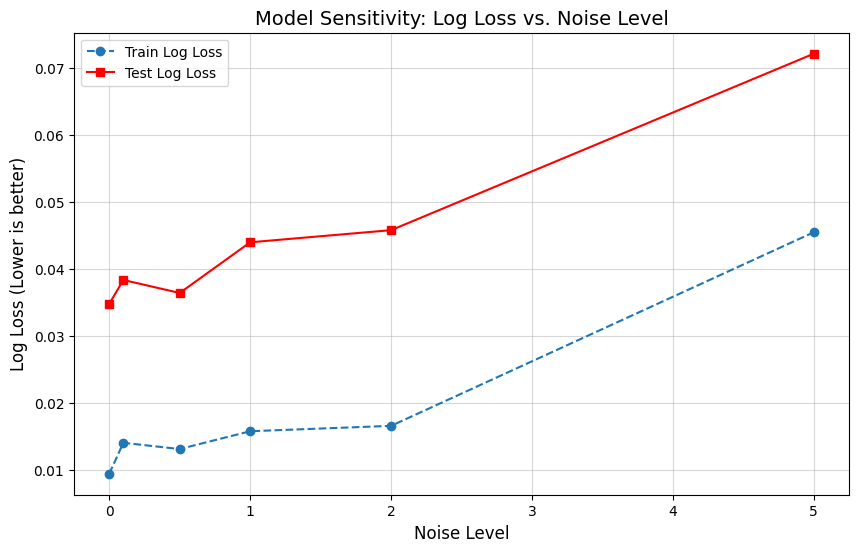

CPU times: total: 9.31 s
Wall time: 9.46 s


In [27]:
%%time

noise_levels = [0, 0.1, 0.5, 1.0, 2.0, 5.0]
train_losses = []
test_losses = []

for level in noise_levels:
    # 產生雜訊數據
    X_test_noisy_temp = add_gaussian_noise(X_test_final_merged, level)
    X_train_noisy_temp = add_gaussian_noise(X_train_final_merged, level)
    
    # 預測機率
    prob_train = sig_clf.predict_proba(X_train_noisy_temp)
    prob_test = sig_clf.predict_proba(X_test_noisy_temp)
    
    # 計算並存入 Loss
    train_losses.append(log_loss(y_train_final_merged, prob_train))
    test_losses.append(log_loss(y_test_final_merged, prob_test))

# 繪製趨勢圖
plt.figure(figsize=(10, 6))
plt.plot(noise_levels, train_losses, label='Train Log Loss', marker='o', linestyle='--')
plt.plot(noise_levels, test_losses, label='Test Log Loss', marker='s', color='red')
plt.title(f'Model Sensitivity: Log Loss vs. Noise Level', fontsize=14)
plt.xlabel('Noise Level', fontsize=12)
plt.ylabel('Log Loss (Lower is better)', fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


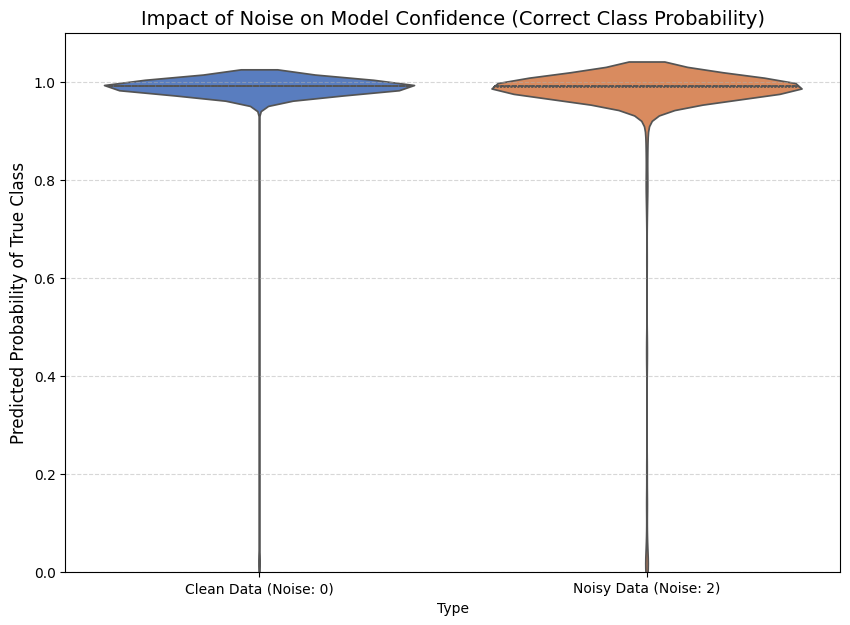

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 假設你的模型是 sig_clf (或是 rf_model / x_clf)
model = sig_clf
noise_level = 2

# --- 1. 獲取機率 ---
# 乾淨數據的預測機率
probs_clean = model.predict_proba(X_test_final_merged)
# 雜訊數據的預測機率 (使用你剛產生的 X_test_noisy)
probs_noisy = model.predict_proba(X_test_noisy_temp)

# --- 2. 提取正確類別的機率 ---
# 我們只需要模型對「真實標籤」所給出的機率分數
clean_correct_probs = probs_clean[np.arange(len(y_test_final_merged)), y_test_final_merged]
noisy_correct_probs = probs_noisy[np.arange(len(y_test_final_merged)), y_test_final_merged]

# --- 3. 整理成 DataFrame ---
df_clean = pd.DataFrame({'Probability': clean_correct_probs, 'Type': 'Clean Data (Noise: 0)'})
df_noisy = pd.DataFrame({'Probability': noisy_correct_probs, 'Type': f'Noisy Data (Noise: {noise_level})'})
df_plot = pd.concat([df_clean, df_noisy])

# --- 4. 繪圖 ---
plt.figure(figsize=(10, 7))
sns.violinplot(x='Type', y='Probability', data=df_plot, inner="quartile", palette="muted")
plt.title(f'Impact of Noise on Model Confidence (Correct Class Probability)', fontsize=14)
plt.ylabel('Predicted Probability of True Class', fontsize=12)
plt.ylim(0, 1.1) # 機率範圍 0~1
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

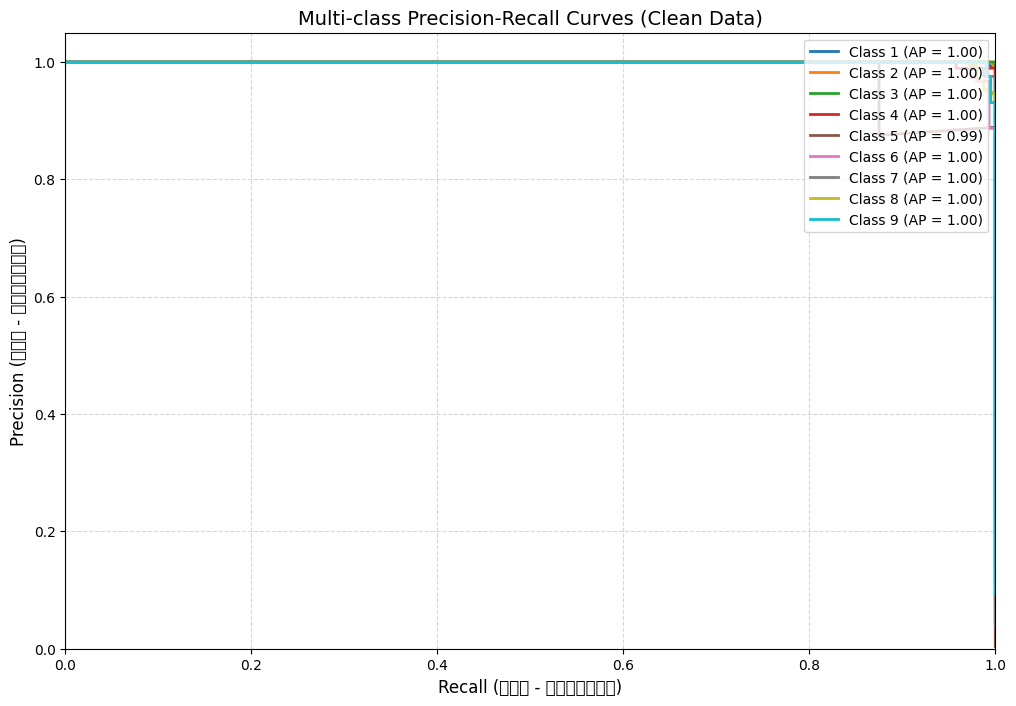

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 數據準備 ---
# PR 曲線需要二值化的標籤 (One-Hot 編碼)
n_classes = len(np.unique(y_test_final_merged))
y_test_binarized = label_binarize(y_test_final_merged, classes=np.arange(n_classes))

# 獲取預測機率 (使用乾淨數據，或是你可以換成 X_test_noisy 看看雜訊下的 PR)
# 假設使用之前 RandomizedSearchCV 找到的最佳 XGBoost 模型
y_score = sig_clf.predict_proba(X_test_final_merged)

# --- 2. 計算每一類的 PR 曲線和 AP 分數 ---
precision = dict()
recall = dict()
average_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_binarized[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_test_binarized[:, i], y_score[:, i])

# --- 3. 繪圖 ---
plt.figure(figsize=(12, 8))

# 定義 9 種不同的顏色
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'Class {i+1} (AP = {average_precision[i]:.2f})')

plt.xlabel('Recall (召回率 - 抓出病毒的能力)', fontsize=12)
plt.ylabel('Precision (精確率 - 判斷正確的能力)', fontsize=12)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Multi-class Precision-Recall Curves (Clean Data)', fontsize=14)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# --- 1. 取得兩組預測結果 ---
# 乾淨數據的預測
y_pred_clean = sig_clf.predict(X_test_final_merged)

# 雜訊數據的預測 (這裡確保你使用的是雜訊等級為 2 的 X_test_noisy)
# 如果你是用剛剛產生的 X_test_noisy_temp，請替換名稱
y_pred_noisy = sig_clf.predict(X_test_noisy_temp) 

# --- 2. 計算混淆矩陣 ---
cm_clean = confusion_matrix(y_test_final_merged, y_pred_clean)
cm_noisy = confusion_matrix(y_test_final_merged, y_pred_noisy)



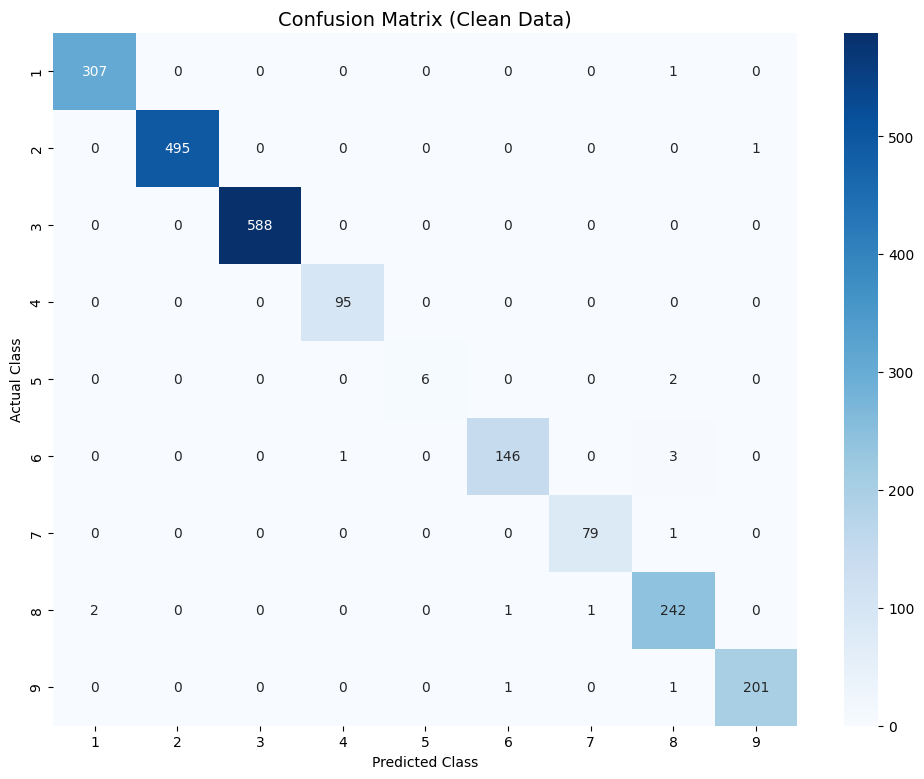

In [22]:
# --- 3. 繪圖 (左右對比) ---
plt.figure(figsize=(12,9))
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 10), yticklabels=range(1, 10))
plt.title('Confusion Matrix (Clean Data)', fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

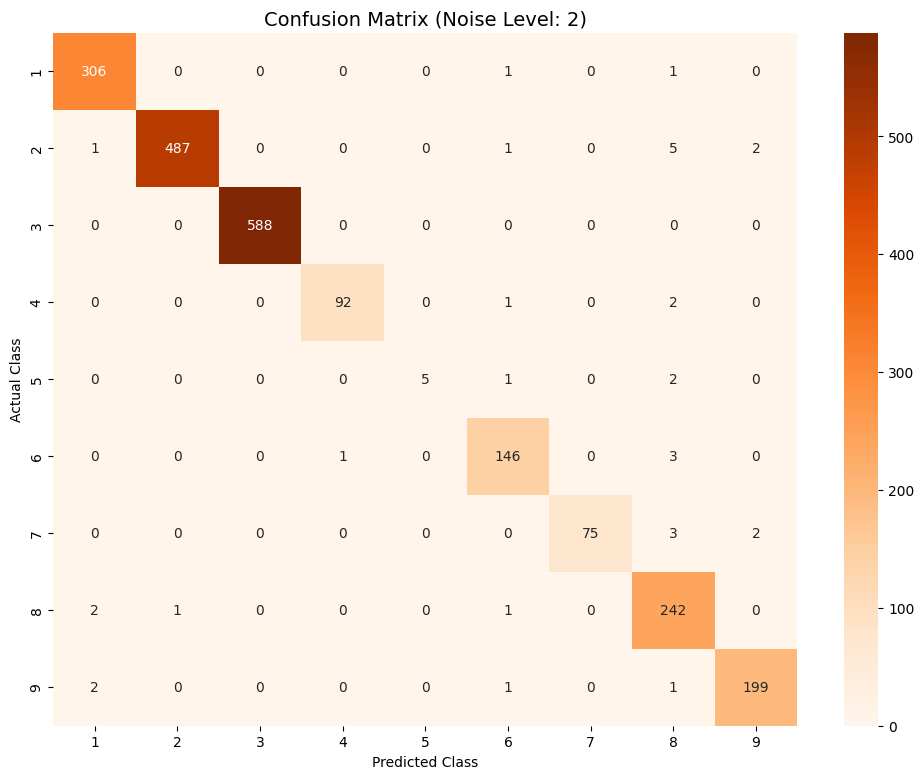

In [23]:
plt.figure(figsize=(12,9))
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Oranges',
            xticklabels=range(1, 10), yticklabels=range(1, 10))
plt.title(f'Confusion Matrix (Noise Level: {noise_level})', fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

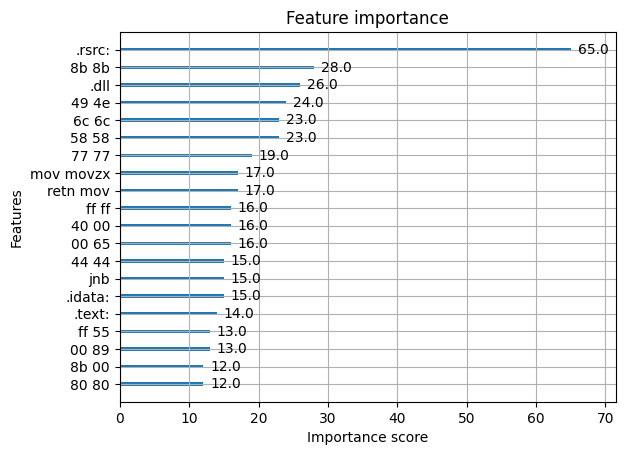

In [24]:
from xgboost import plot_importance
plot_importance(x_clf_with_best_hyper_param, max_num_features=20)
plt.show()

In [25]:
from sklearn.metrics import accuracy_score, classification_report, log_loss

# 1. 使用校準後的模型進行預測
# 預測類別 (用於計算 Accuracy)
y_pred = sig_clf.predict(X_test_final_merged) 
# 預測機率 (用於計算 Log-loss，這是 TA 想看的專業指標)
y_pred_proba = sig_clf.predict_proba(X_test_final_merged)

# 2. 計算準確率 (Accuracy)
acc = accuracy_score(y_test_final_merged, y_pred)
print(f"Accuracy: {acc:.4f}")

# 3. 計算 Log-Loss 
# 因為你用了 CalibratedClassifierCV，這個數值應該會比沒校準前更好
loss = log_loss(y_test_final_merged, y_pred_proba)
print(f"Log Loss: {loss:.4f}")

# 4. 列出每一類惡意程式的 Precision, Recall, F1-score
# 這能回答 TA 關於「如何分析執行檔」的問題
print("Detail Report:")
print(classification_report(y_test_final_merged, y_pred))

Accuracy: 0.9931
Log Loss: 0.0347
Detail Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       308
           1       1.00      1.00      1.00       496
           2       1.00      1.00      1.00       588
           3       0.99      1.00      0.99        95
           4       1.00      0.75      0.86         8
           5       0.99      0.97      0.98       150
           6       0.99      0.99      0.99        80
           7       0.97      0.98      0.98       246
           8       1.00      0.99      0.99       203

    accuracy                           0.99      2174
   macro avg       0.99      0.96      0.98      2174
weighted avg       0.99      0.99      0.99      2174



In [99]:
def normalize(df):
    result1 = df.copy()
    for feature_name in df.columns:
        if (str(feature_name) != str('ID') and str(feature_name)!=str('Class')):
            max_value = df[feature_name].max()
            min_value = df[feature_name].min()
            result1[feature_name] = (df[feature_name] - min_value) / (max_value - min_value)
    return result1